5 Baris pertama dataset:
         date   meantemp   humidity  wind_speed  meanpressure
0  2013-01-01  10.000000  84.500000    0.000000   1015.666667
1  2013-01-02   7.400000  92.000000    2.980000   1017.800000
2  2013-01-03   7.166667  87.000000    4.633333   1018.666667
3  2013-01-04   8.666667  71.333333    1.233333   1017.166667
4  2013-01-05   6.000000  86.833333    3.700000   1016.500000

Jumlah data kosong (null) per kolom:
date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64


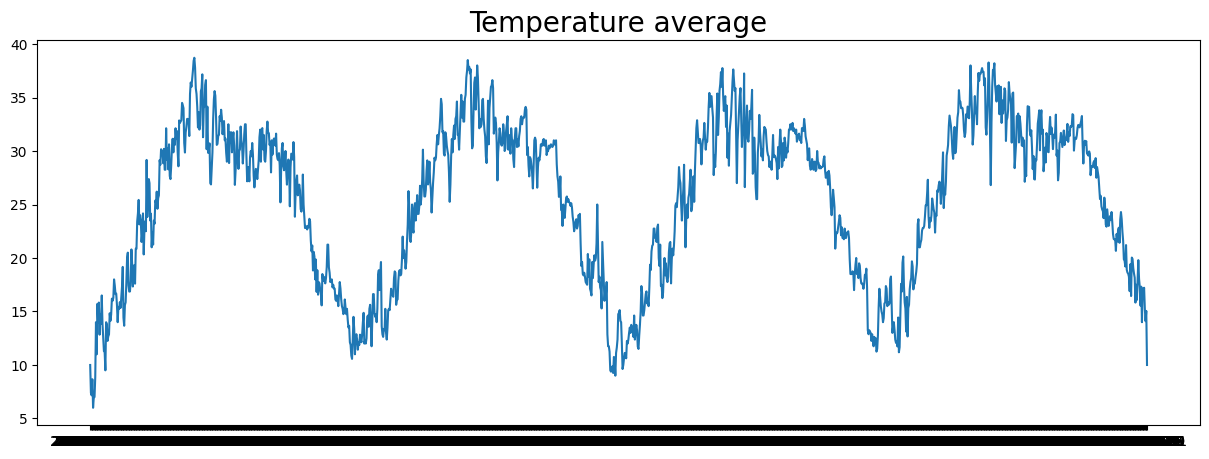

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 98ms/step - loss: 25.3584 - mae: 25.8584
Epoch 2/100


c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step - loss: 25.1471 - mae: 25.6471
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 134ms/step - loss: 24.8968 - mae: 25.3968
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - loss: 24.6517 - mae: 25.1517
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - loss: 24.4103 - mae: 24.9103
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - loss: 24.1522 - mae: 24.6522
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - loss: 23.8650 - mae: 24.3650
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step - loss: 23.5281 - mae: 24.0281
Epoch 9/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 23.1195 - mae: 23.6195
Epoch 10/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 22.6273 - mae: 23.1273
Epoch 11/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 22.0283 - mae: 22.5283
Epoch 12/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 21.2830 - mae: 21.7830
Epoch 13/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 20.3047 - mae: 20.8047
Epoch

[[18.165375]
 [18.390762]
 [18.601065]
 ...
 [15.785432]
 [15.219119]
 [15.049728]]


In [1]:
# 1. MENGIMPOR PUSTAKA (LIBRARIES)
import numpy as np                 # Digunakan untuk komputasi numerik dan manipulasi array
import pandas as pd                # Digunakan untuk manipulasi dan analisis data tabular (DataFrame)
from keras.layers import Dense, LSTM # Mengimpor layer dari Keras (walaupun nanti di kode menggunakan tf.keras)
import matplotlib.pyplot as plt    # Digunakan untuk membuat visualisasi data (grafik)
import tensorflow as tf            # Pustaka utama untuk membangun dan melatih model Deep Learning

# 2. MEMUAT DAN MENGEKSPLORASI DATA
# Membaca file CSV langsung dari tautan Google Drive menggunakan Pandas
df = pd.read_csv('https://drive.google.com/uc?id=15RfMD9lNkpS3cVN7j3_dsJKZ8_5RJG5z')

# Menampilkan 5 baris pertama dari dataset untuk memastikan data terakses dengan benar
print("5 Baris pertama dataset:")
print(df.head())

# Mengecek apakah ada nilai yang kosong (Missing Values / NaN) pada setiap kolom
print("\nJumlah data kosong (null) per kolom:")
print(df.isnull().sum())

# 3. MEMILIH FITUR YANG AKAN DIGUNAKAN
# Mengambil nilai dari kolom 'date' sebagai array NumPy untuk sumbu X (waktu)
dates = df['date'].values
# Mengambil nilai dari kolom 'meantemp' sebagai array NumPy untuk sumbu Y (target prediksi)
temp = df['meantemp'].values

# Membagi data menjadi dua bagian: 80% untuk pelatihan (training) dan 20% untuk pengujian (testing)
# Menentukan titik potong
split_time = int(len(temp) * 0.8)

# Membagi Data (Splitting)
x_train = temp[:split_time]     # Mengambil 80% data pertama
time_train = dates[:split_time] 

x_test = temp[split_time:]      # Mengambil 20% data terakhir
time_test = dates[split_time:]


# 4. VISUALISASI DATA
# Membuat kanvas grafik dengan ukuran panjang 15 dan lebar 5
plt.figure(figsize=(15,5))
# Membuat plot garis (line chart) antara waktu (dates) dan suhu (temp)
plt.plot(dates, temp)
# Memberikan judul pada grafik dengan ukuran font 20
plt.title('Temperature average', fontsize=20)
# Menampilkan grafik ke layar
plt.show()

# 5. FUNGSI PREPROCESSING DATA (SLIDING WINDOW)
def windowed_dataset(series, window_size, batch_size, shuffle_buffer):
    """
    Fungsi ini mengubah data deret waktu 1D menjadi format dataset yang siap dilatih 
    oleh model Machine Learning menggunakan teknik 'Sliding Window'.
    """
    # Menambahkan satu dimensi ekstra di akhir. Model RNN/LSTM membutuhkan input 3D (batch, timesteps, features)
    series = tf.expand_dims(series, axis=-1) 
    
    # Membuat objek tf.data.Dataset dari array NumPy
    ds = tf.data.Dataset.from_tensor_slices(series) 
    
    # Mengelompokkan data menjadi 'jendela' (window). 
    # Ukurannya window_size + 1 karena elemen terakhir akan dijadikan label (target)
    ds = ds.window(window_size + 1, shift=1, drop_remainder=True) 
    
    # Mengubah dataset of datasets menjadi dataset tunggal yang rata (flatten) ke dalam batch
    ds = ds.flat_map(lambda w: w.batch(window_size + 1)) 
    
    # Mengacak urutan data agar model tidak menghafal urutan (mencegah overfitting)
    ds = ds.shuffle(shuffle_buffer) 
    
    # Memisahkan data menjadi Fitur (X) dan Label/Target (Y)
    # w[:-1] mengambil semua data dari awal hingga sebelum elemen terakhir sebagai fitur input
    # w[-1:] mengambil elemen paling akhir sebagai target prediksi
    ds = ds.map(lambda w: (w[:-1], w[-1:])) 
    
    # Mengelompokkan data ke dalam ukuran 'batch_size' dan menggunakan prefetch untuk efisiensi memori
    return ds.batch(batch_size).prefetch(1)

# 6. MEMBANGUN ARSITEKTUR MODEL
# Menerapkan fungsi windowed_dataset ke data suhu (temp)
# Menggunakan 60 data masa lalu untuk memprediksi 1 data di masa depan
train_set = windowed_dataset(temp, window_size=60, batch_size=100, shuffle_buffer=1000) # untuk data latih
test_set = windowed_dataset(temp, window_size=60, batch_size=100, shuffle_buffer=1)  # untuk data uji 

# Membangun model jaringan saraf tiruan (Neural Network) secara berurutan (Sequential)
model = tf.keras.models.Sequential([
    # Layer LSTM pertama dengan 60 unit. return_sequences=True wajib dipakai jika 
    # layer setelahnya juga merupakan layer RNN/LSTM.
    tf.keras.layers.LSTM(60, return_sequences=True),
    
    # Layer LSTM kedua dengan 60 unit.
    tf.keras.layers.LSTM(60),
    
    # Layer Dense (Fully Connected) dengan 30 neuron dan fungsi aktivasi ReLU
    tf.keras.layers.Dense(30, activation="relu"),
    
    # Layer Dense dengan 10 neuron dan fungsi aktivasi ReLU
    tf.keras.layers.Dense(10, activation="relu"),
    
    # Layer Output (1 neuron) karena kita hanya memprediksi 1 nilai berkelanjutan (suhu)
    tf.keras.layers.Dense(1),
])

# 7. MENENTUKAN OPTIMIZER DAN LOSS FUNCTION
# Menggunakan Stochastic Gradient Descent (SGD) sebagai optimizer 
# learning_rate diatur sangat kecil (0.0001) dan momentum 0.9 untuk percepatan konvergensi
optimizer = tf.keras.optimizers.SGD(learning_rate=1.0000e-04, momentum=0.9) 

# Mengkompilasi model:
# - loss: Huber() sangat baik untuk regresi karena tahan terhadap data pencilan (outliers)
# - optimizer: menggunakan SGD yang sudah didefinisikan
# - metrics: 'mae' (Mean Absolute Error) untuk melihat rata-rata selisih mutlak error prediksi
model.compile(loss=tf.keras.losses.Huber(),
              optimizer=optimizer,
              metrics=["mae"])

# 8. MELATIH MODEL
# Melakukan proses training sebanyak 100 epoch (putaran)
history = model.fit(train_set, epochs=100)

# 9. MELAKUKAN PREDIKSI
# Menggunakan model yang telah dilatih untuk memprediksi ulang data pada test_set
forecast = history.model.predict(test_set)

# Menampilkan hasil prediksi
print(forecast)

model.save('model.h5') # Menyimpan model yang sudah dilatih ke dalam file 'model.h5' untuk digunakan nanti tanpa perlu melatih ulang